# Model Explorer

Load a trained model from `models/{run_id}/` and run it on train/validation data.

**Usage:** Set `RUN_ID` below to the run ID you want to load (e.g. `"mlx_smoke_20260324_143052"`).
The notebook will:
1. Extract the model definition from `models/{run_id}/log.txt` (which contains the training script)
2. Load weights from the quantized `model.int8.ptz` checkpoint (or raw `model.npz`)
3. Load train and validation data using baseline data loading utilities
4. Let you run the model on examples and inspect predictions

In [1]:
# === CONFIGURATION ===
# Set this to the run ID of the model you want to load.
# Available runs can be found with: !ls models/
RUN_ID = "baseline_20k_iters_seq2_20260324_205335"

# Whether to load the quantized (int8) or raw (fp32) checkpoint
USE_QUANTIZED = True

# Sequence length for data batches
SEQ_LEN = 1024

# Data paths (defaults match the baseline)
DATA_PATH = "./data/datasets/fineweb10B_sp1024"
TOKENIZER_PATH = "./data/tokenizers/fineweb_1024_bpe.model"

In [2]:
import glob
import importlib.util
import io
import os
import sys
import tempfile
import zlib
from pathlib import Path

import numpy as np
import sentencepiece as spm
import torch

## 1. Load the training script from the log file

The `.txt` log files contain the full training script followed by training output.
We extract just the Python source, write it to a temp file, and import it as a module.
This gives us the exact model class and hyperparameters that were used for training.

In [3]:
run_dir = Path("models") / RUN_ID
log_txt = run_dir / "log.txt"
assert log_txt.exists(), f"Log file not found: {log_txt}"

# Determine checkpoint path
if USE_QUANTIZED:
    ckpt_path = run_dir / "model.int8.ptz"
else:
    ckpt_path = run_dir / "model.npz"
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

print(f"Run dir:    {run_dir}")
print(f"Log file:   {log_txt}")
print(f"Checkpoint: {ckpt_path} ({ckpt_path.stat().st_size / 1e6:.1f} MB)")

Run dir:    models/baseline_20k_iters_seq2_20260324_205335
Log file:   models/baseline_20k_iters_seq2_20260324_205335/log.txt
Checkpoint: models/baseline_20k_iters_seq2_20260324_205335/model.int8.ptz (15.8 MB)


In [4]:
# Extract the Python source from the log file.
# The log format is: full training script, then training output lines.
# We find where the script ends by looking for the if __name__ block and its body.
raw_lines = log_txt.read_text().splitlines()

# Find the end of the Python source: after `if __name__` block, the first line
# that looks like training output (e.g. "step:" or non-Python) marks the boundary.
in_main = False
source_end = len(raw_lines)
for i, line in enumerate(raw_lines):
    if line.strip().startswith("if __name__"):
        in_main = True
    if in_main and i > 0:
        # Training output lines start with known prefixes or are unindented non-Python
        stripped = line.strip()
        if stripped and not stripped.startswith("#") and ":" in stripped:
            # Check if it looks like a log line (e.g. "step:1/200" or "saved_model:...")
            first_token = stripped.split(":")[0].split("(")[0].split("[")[0]
            if first_token in (
                "step",
                "val_progress",
                "saved_model",
                "serialized_model_int8_zlib",
                "final_int8_zlib_roundtrip",
                "final_int8_zlib_roundtrip_exact",
                "stopping_early",
                "WARNING",
            ):
                source_end = i
                break

script_source = "\n".join(raw_lines[:source_end])
print(f"Extracted {source_end} lines of Python source from {log_txt.name}")

Extracted 1414 lines of Python source from log.txt


In [5]:
# Import the training script as a module (without running __main__)
# We strip the if __name__ == "__main__" block to avoid executing training.
main_idx = None
for i, line in enumerate(raw_lines[:source_end]):
    if line.strip().startswith("if __name__"):
        main_idx = i
        break

importable_source = "\n".join(raw_lines[:main_idx]) if main_idx else script_source

# Write to a temp file and import
_tmpdir = tempfile.mkdtemp()
_tmp_path = os.path.join(_tmpdir, f"{RUN_ID.replace('-', '_')}_module.py")
with open(_tmp_path, "w") as f:
    f.write(importable_source)

spec = importlib.util.spec_from_file_location("train_module", _tmp_path)
train_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(train_module)

print(
    f"Imported module with attributes: {[a for a in dir(train_module) if not a.startswith('_')][:20]}"
)

Imported module with attributes: ['BOS_ID', 'Block', 'CONTROL_TENSOR_NAME_PATTERNS', 'CastedLinear', 'CausalSelfAttention', 'DDP', 'DistributedTokenLoader', 'F', 'GPT', 'Hyperparameters', 'INT8_CLIP_PERCENTILE', 'INT8_CLIP_Q', 'INT8_KEEP_FLOAT_FP32_NAME_PATTERNS', 'INT8_KEEP_FLOAT_MAX_NUMEL', 'INT8_KEEP_FLOAT_STORE_DTYPE', 'INT8_PER_ROW_SCALE_DTYPE', 'MLP', 'Muon', 'Path', 'RMSNorm']


## 2. Instantiate the model and load weights

In [6]:
# Get hyperparameters from the imported module
hp = train_module.Hyperparameters()
print("Hyperparameters:")
for field in [
    "vocab_size",
    "num_layers",
    "model_dim",
    "num_heads",
    "num_kv_heads",
    "mlp_mult",
    "tie_embeddings",
    "logit_softcap",
    "rope_base",
]:
    if hasattr(hp, field):
        print(f"  {field}: {getattr(hp, field)}")

Hyperparameters:
  vocab_size: 1024
  num_layers: 9
  model_dim: 512
  num_heads: 8
  num_kv_heads: 4
  mlp_mult: 2
  tie_embeddings: True
  logit_softcap: 30.0
  rope_base: 10000.0


In [7]:
# Build the model using the same constructor args from the training script.
# The GPT class signature can vary between records, so we introspect.
import inspect

GPT = train_module.GPT
sig = inspect.signature(GPT.__init__)
init_params = [p for p in sig.parameters if p != "self"]
print(f"GPT.__init__ params: {init_params}")

# Map from common init param names to hyperparameter fields
param_map = {
    "vocab_size": hp.vocab_size,
    "num_layers": hp.num_layers,
    "dim": hp.model_dim,
    "num_heads": hp.num_heads,
    "num_kv_heads": hp.num_kv_heads,
    "mlp_mult": hp.mlp_mult,
    "logit_chunk_tokens": getattr(hp, "logit_chunk_tokens", 0),
    "logit_softcap": getattr(hp, "logit_softcap", 30.0),
    "rope_base": getattr(hp, "rope_base", 10000.0),
    "tied_embed_init_std": getattr(hp, "tied_embed_init_std", 0.005),
    "qk_gain_init": getattr(hp, "qk_gain_init", 1.5),
}

# Build kwargs from what the constructor actually accepts
kwargs = {}
for p in init_params:
    if p in param_map:
        kwargs[p] = param_map[p]
    else:
        # Try getting it from hyperparameters directly
        if hasattr(hp, p):
            kwargs[p] = getattr(hp, p)
        else:
            print(f"  WARNING: unknown init param '{p}' — using default")

print(f"\nConstructing GPT with: {kwargs}")
model = GPT(**kwargs)
print(f"Model created successfully.")

GPT.__init__ params: ['vocab_size', 'num_layers', 'model_dim', 'num_heads', 'num_kv_heads', 'mlp_mult', 'tie_embeddings', 'tied_embed_init_std', 'logit_softcap', 'rope_base', 'qk_gain_init']

Constructing GPT with: {'vocab_size': 1024, 'num_layers': 9, 'model_dim': 512, 'num_heads': 8, 'num_kv_heads': 4, 'mlp_mult': 2, 'tie_embeddings': True, 'tied_embed_init_std': 0.005, 'logit_softcap': 30.0, 'rope_base': 10000.0, 'qk_gain_init': 1.5}
Model created successfully.


In [8]:
# Load checkpoint weights
if USE_QUANTIZED:
    with open(ckpt_path, "rb") as f:
        quant_blob = f.read()
    quant_obj = torch.load(io.BytesIO(zlib.decompress(quant_blob)), map_location="cpu")
    state_dict = train_module.dequantize_state_dict_int8(quant_obj)
    print(f"Loaded quantized checkpoint: {len(state_dict)} tensors")
else:
    state_dict = torch.load(ckpt_path, map_location="cpu")
    print(f"Loaded raw checkpoint: {len(state_dict)} tensors")

model.load_state_dict(state_dict, strict=True)
model.eval()

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Loaded quantized checkpoint: 92 tensors
Model parameters: 17,059,912


## 3. Load tokenizer and data

In [9]:
# Load tokenizer
sp = spm.SentencePieceProcessor(model_file=TOKENIZER_PATH)
print(f"Tokenizer loaded: vocab_size={sp.vocab_size()}")

Tokenizer loaded: vocab_size=1024


In [10]:
# Import data loading utilities from train_gpt.py (PyTorch)
sys.path.insert(0, str(Path(".").resolve()))
from train_gpt import (
    load_validation_tokens,
    TokenStream,
    build_sentencepiece_luts,
)

# Load validation tokens
val_pattern = f"{DATA_PATH}/fineweb_val_*.bin"
val_tokens = load_validation_tokens(val_pattern, seq_len=SEQ_LEN)
print(
    f"Validation tokens: {val_tokens.shape[0]:,} (enough for {(val_tokens.shape[0] - 1) // SEQ_LEN} sequences)"
)
n_documents = int((val_tokens == 1).sum())
print(
    f"Found {n_documents} documents in validation set (start tokens). "
    f"Average document length: {val_tokens.shape[0] / n_documents:.1f} tokens."
)

# Set up train data loader
train_pattern = f"{DATA_PATH}/fineweb_train_*.bin"
train_stream = TokenStream(train_pattern)
print(f"Train stream ready.")

# Build byte counting LUTs for BPB calculation
base_bytes_lut, has_leading_space_lut, is_boundary_token_lut = build_sentencepiece_luts(
    sp, hp.vocab_size, torch.device("cpu")
)

Validation tokens: 62,021,633 (enough for 60568 sequences)
Found 50000 documents in validation set (start tokens). Average document length: 1240.4 tokens.
Train stream ready.


Mean document length: 1240.4 tokens


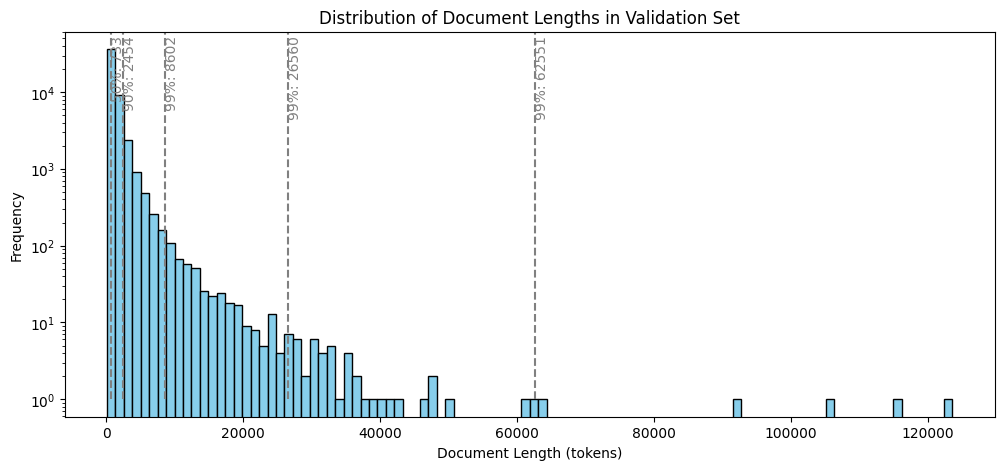

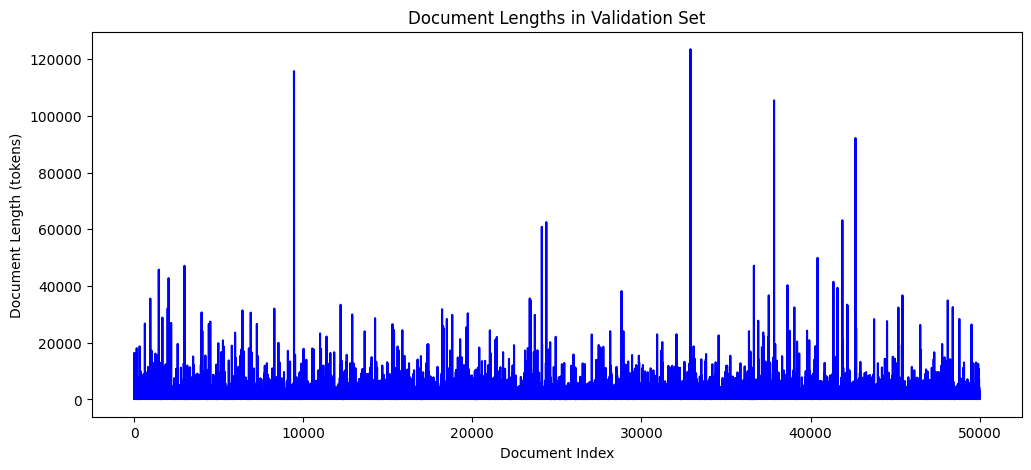

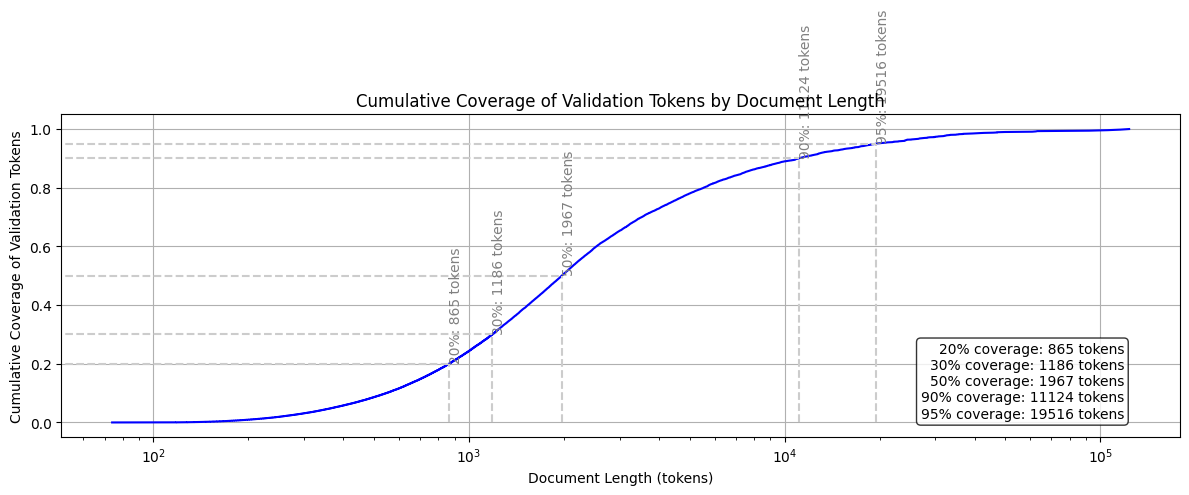

In [11]:
from matplotlib import pyplot as plt
from numpy import mean

# indices of start tokens
start_token_indices = np.where(val_tokens == 1)[0]

# length of each document (distance between start tokens)
doc_lengths = np.diff(start_token_indices, append=len(val_tokens))
mean_doc_length = mean(doc_lengths)
print(f"Mean document length: {mean_doc_length:.1f} tokens")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(doc_lengths, bins=100, color="skyblue", edgecolor="black")
ax.set_xlabel("Document Length (tokens)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Document Lengths in Validation Set")
ax.set_yscale("log")
for quantile in [0.5, 0.9, 0.99, 0.999, 0.9999]:
    color = "0.5"
    q_value = np.quantile(doc_lengths, quantile)
    ax.vlines(q_value, ymin=1, ymax=ax.get_ylim()[1], colors=color, linestyles="dashed")
    ax.text(
        q_value,
        ax.get_ylim()[1] * 0.9,
        f"{int(quantile * 100)}%: {q_value:.0f}",
        rotation=90,
        verticalalignment="top",
        color=color,
    )

# plot sequence of document lengths
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(doc_lengths, color="blue")
ax.set_xlabel("Document Index")
ax.set_ylabel("Document Length (tokens)")
ax.set_title("Document Lengths in Validation Set")

# cumulative total tokens covered
sorted_lengths = np.sort(doc_lengths)
cumulative_tokens = np.cumsum(sorted_lengths)
total_tokens = cumulative_tokens[-1]
cumulative_coverage = cumulative_tokens / total_tokens

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sorted_lengths, cumulative_coverage, color="blue")
ax.set_xlabel("Document Length (tokens)")
ax.set_ylabel("Cumulative Coverage of Validation Tokens")
ax.set_title("Cumulative Coverage of Validation Tokens by Document Length")
ax.grid(True)
coverages = {}
for coverage in [0.2, 0.3, 0.5, 0.9, 0.95]:
    color = "0.8"
    idx = np.searchsorted(cumulative_coverage, coverage)
    length_at_coverage = sorted_lengths[idx]
    coverages[coverage] = length_at_coverage
    ax.vlines(
        length_at_coverage,
        ymin=0,
        ymax=coverage,
        colors=color,
        linestyles="dashed",
    )
    ax.hlines(
        coverage,
        xmin=0,
        xmax=length_at_coverage,
        colors=color,
        linestyles="dashed",
    )
    ax.text(
        length_at_coverage,
        coverage,
        f"{int(coverage * 100)}%: {length_at_coverage:.0f} tokens",
        rotation=90,
        verticalalignment="bottom",
        color="0.5",
    )


# text box with coverage info
textstr = "\n".join(
    [
        f"{int(cov * 100)}% coverage: {length} tokens"
        for cov, length in coverages.items()
    ]
)
props = dict(boxstyle="round", facecolor="white", alpha=0.8)
ax.text(
    0.95,
    0.05,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="right",
    bbox=props,
)
ax.set_xscale("log")
plt.tight_layout()
plt.show()

In [12]:
# Factual recall / knowledge token analysis
# Per document (BOS token id=1), find knowledge-bearing spans (numbers, proper nouns)
# in the decoded text, map them back to token counts, and check if they repeat in the doc.
import re
from collections import Counter

BOS_ID = 1
pieces = [sp.id_to_piece(int(tid)) for tid in range(sp.vocab_size())]

# Build a mapping: for each token, how many decoded characters does it produce?
# SentencePiece ▁ = one space character
piece_lens = []
for p in pieces:
    piece_lens.append(len(p.replace("▁", " ")))

# Patterns to find in decoded text
# Numbers: sequences of digits, possibly with internal commas/periods (e.g. 1,000 or 3.14)
number_re = re.compile(r"\b\d[\d,]*\.?\d*\b")
# Proper nouns: capitalized words not at sentence start.
# We find all capitalized words, then filter out sentence-initial ones.
# A proper noun: uppercase letter followed by lowercase letters, possibly hyphenated/multi-word
name_re = re.compile(r"\b[A-Z][a-z]+(?:[\s'-][A-Z][a-z]+)*\b")
# Sentence boundary: .!?:" followed by space (to detect sentence-initial caps)
sent_end_re = re.compile(r"[.!?:]\s*$")

# Common words that are often capitalized but aren't proper nouns
COMMON_CAPS = {
    "The",
    "This",
    "That",
    "These",
    "Those",
    "There",
    "Their",
    "They",
    "Then",
    "When",
    "Where",
    "What",
    "Which",
    "While",
    "Who",
    "Why",
    "How",
    "Here",
    "His",
    "Her",
    "He",
    "She",
    "Its",
    "Our",
    "Your",
    "My",
    "But",
    "And",
    "For",
    "Not",
    "Are",
    "Was",
    "Were",
    "Has",
    "Had",
    "Have",
    "Will",
    "Would",
    "Could",
    "Should",
    "May",
    "Can",
    "Did",
    "Does",
    "Been",
    "Being",
    "With",
    "From",
    "Into",
    "Over",
    "After",
    "Before",
    "Between",
    "Under",
    "About",
    "Some",
    "Many",
    "Most",
    "Other",
    "Each",
    "Every",
    "Both",
    "Such",
    "Just",
    "Also",
    "Now",
    "Still",
    "Even",
    "Only",
    "Very",
    "More",
    "Much",
    "Any",
    "All",
    "One",
    "Two",
    "Three",
    "Four",
    "Five",
    "Six",
    "Seven",
    "Eight",
    "Nine",
    "Ten",
    "First",
    "Last",
    "New",
    "Old",
    "Good",
    "Great",
    "Big",
    "Small",
    "Long",
    "High",
    "Low",
    "Few",
    "Less",
    "Like",
    "Well",
    "Way",
    "Day",
    "Time",
    "Year",
    "People",
    "Part",
    "Place",
    "Case",
    "Week",
    "Company",
    "System",
    "Program",
    "Question",
    "Work",
    "Government",
    "Number",
    "Night",
    "Point",
    "Home",
    "Water",
    "Room",
    "Mother",
    "Area",
    "Money",
    "Story",
    "Fact",
    "Month",
    "Lot",
    "Right",
    "Study",
    "Book",
    "Eye",
    "Job",
    "Word",
    "Business",
    "Issue",
    "Side",
    "Kind",
    "Head",
    "House",
    "Service",
    "Friend",
    "Father",
    "Power",
    "Hour",
    "Game",
    "Line",
    "End",
    "Members",
    "Family",
    "Back",
    "According",
    "However",
    "Although",
    "Because",
    "Since",
    "Whether",
    "Another",
    "During",
    "Without",
    "Something",
    "Everything",
    "Nothing",
    "Perhaps",
    "Instead",
    "Despite",
    "Rather",
    "Together",
    "Already",
    "Probably",
    "Often",
    "Sometimes",
    "Never",
    "Always",
    "If",
    "It",
    "In",
    "Is",
    "So",
    "Or",
    "As",
    "At",
    "By",
    "No",
    "We",
    "An",
    "On",
    "Do",
    "Up",
}

doc_starts = np.where(val_tokens == BOS_ID)[0]
doc_boundaries = np.concatenate([doc_starts, [len(val_tokens)]])

total_tokens = 0
num_tok = 0
name_tok = 0
num_facts = 0
name_facts = 0
num_facts_first = 0
num_facts_repeat = 0
name_facts_first = 0
name_facts_repeat = 0
num_tok_first = 0
num_tok_repeat = 0
name_tok_first = 0
name_tok_repeat = 0

examples = []
MAX_EXAMPLES = 2000
CTX_CHARS = 40

for di in range(len(doc_boundaries) - 1):
    start, end = int(doc_boundaries[di]), int(doc_boundaries[di + 1])
    doc_toks = val_tokens[start:end]
    doc_len = len(doc_toks)
    if doc_len < 2:
        continue
    total_tokens += doc_len

    # Decode document and build char->token mapping
    char_to_tok = []  # for each character in decoded text, which token index produced it
    decoded_chars = []
    for pos in range(doc_len):
        tid = int(doc_toks[pos])
        p = pieces[tid] if tid < len(pieces) else ""
        text = p.replace("▁", " ")
        for ch in text:
            decoded_chars.append(ch)
            char_to_tok.append(pos)
    decoded_text = "".join(decoded_chars)

    # Find all facts in decoded text
    facts_in_doc = []  # (char_start, char_end, text, type)

    # Numbers
    for m in number_re.finditer(decoded_text):
        facts_in_doc.append((m.start(), m.end(), m.group(), "num"))

    # Names: capitalized words, filtering out sentence-initial and common words
    for m in name_re.finditer(decoded_text):
        name = m.group()
        # Skip common words
        first_word = name.split()[0].split("'")[0].split("-")[0]
        if first_word in COMMON_CAPS:
            continue
        # Skip if at very start of doc (first 3 chars)
        if m.start() < 3:
            continue
        # Skip if preceded by sentence-ending punctuation
        prefix = decoded_text[max(0, m.start() - 3) : m.start()]
        if sent_end_re.search(prefix):
            continue
        facts_in_doc.append((m.start(), m.end(), name, "name"))

    # For each fact: count tokens it spans, check if text appeared earlier
    seen_texts = set()
    for cs, ce, text, kind in sorted(facts_in_doc):
        # Count unique token indices spanned
        tok_indices = set(char_to_tok[cs:ce])
        n_toks = len(tok_indices)

        is_first = text not in seen_texts
        seen_texts.add(text)

        if kind == "num":
            num_facts += 1
            num_tok += n_toks
            if is_first:
                num_facts_first += 1
                num_tok_first += n_toks
            else:
                num_facts_repeat += 1
                num_tok_repeat += n_toks
        else:
            name_facts += 1
            name_tok += n_toks
            if is_first:
                name_facts_first += 1
                name_tok_first += n_toks
            else:
                name_facts_repeat += 1
                name_tok_repeat += n_toks

        if len(examples) < MAX_EXAMPLES:
            ctx_b = decoded_text[max(0, cs - CTX_CHARS) : cs]
            ctx_a = decoded_text[ce : ce + CTX_CHARS]
            examples.append(
                {
                    "type": kind,
                    "fact": text,
                    "n_tokens": n_toks,
                    "first_occ": is_first,
                    "context": f"...{ctx_b}[{text}]{ctx_a}...",
                    "doc_idx": di,
                }
            )

print(f"Total tokens: {total_tokens:,}")
print(f"Documents: {len(doc_boundaries) - 1:,}")
print()
print("=== Numbers ===")
print(
    f"  Facts: {num_facts:,}  |  Tokens: {num_tok:,} ({100 * num_tok / total_tokens:.2f}%)"
)
print(f"  Avg tokens/fact: {num_tok / max(num_facts, 1):.2f}")
print(
    f"  First occ: {num_facts_first:,} facts, {num_tok_first:,} tok  |  Repeated: {num_facts_repeat:,} facts, {num_tok_repeat:,} tok"
)
print()
print("=== Names (proper nouns) ===")
print(
    f"  Facts: {name_facts:,}  |  Tokens: {name_tok:,} ({100 * name_tok / total_tokens:.2f}%)"
)
print(f"  Avg tokens/fact: {name_tok / max(name_facts, 1):.2f}")
print(
    f"  First occ: {name_facts_first:,} facts, {name_tok_first:,} tok  |  Repeated: {name_facts_repeat:,} facts, {name_tok_repeat:,} tok"
)
print()
tk = num_tok + name_tok
tf = num_facts + name_facts
tf_first = num_tok_first + name_tok_first
tf_repeat = num_tok_repeat + name_tok_repeat
print(f"=== Combined ===")
print(
    f"  Knowledge tokens: {tk:,} ({100 * tk / total_tokens:.2f}%) in {tf:,} facts ({tk / max(tf, 1):.2f} tok/fact)"
)
print(f"  Factual recall: {tf_first:,} tok ({100 * tf_first / total_tokens:.2f}%)")
print(
    f"  Context-predictable: {tf_repeat:,} tok ({100 * tf_repeat / total_tokens:.2f}%)"
)

# Save examples
import json as _json

with open("knowledge_token_examples.jsonl", "w") as f:
    for ex in examples:
        f.write(_json.dumps(ex) + "\n")
print(f"\nSaved {len(examples)} examples to knowledge_token_examples.jsonl")

# Show samples
for label, kind in [("number", "num"), ("name", "name")]:
    print(f"\n=== Sample {label} facts ===")
    for ex in [e for e in examples if e["type"] == kind][:15]:
        tag = "FIRST" if ex["first_occ"] else "REPEAT"
        print(f"  [{tag}] ({ex['n_tokens']}tok) {ex['context']}")

Total tokens: 62,021,633
Documents: 50,000

=== Numbers ===
  Facts: 565,557  |  Tokens: 1,453,208 (2.34%)
  Avg tokens/fact: 2.57
  First occ: 360,848 facts, 989,815 tok  |  Repeated: 204,709 facts, 463,393 tok

=== Names (proper nouns) ===
  Facts: 1,378,741  |  Tokens: 7,505,871 (12.10%)
  Avg tokens/fact: 5.44
  First occ: 949,623 facts, 5,534,183 tok  |  Repeated: 429,118 facts, 1,971,688 tok

=== Combined ===
  Knowledge tokens: 8,959,079 (14.45%) in 1,944,298 facts (4.61 tok/fact)
  Factual recall: 6,523,998 tok (10.52%)
  Context-predictable: 2,435,081 tok (3.93%)

Saved 2000 examples to knowledge_token_examples.jsonl

=== Sample number facts ===
  [FIRST] (2tok) ...have died sometime in October.” Now the [59]-year-old worries that he will stop gett...
  [FIRST] (2tok) ...he "Good Morning America" Whistle-Stop '[08] Tour train, and beginning the adventure...
  [FIRST] (1tok) ...d say that I loved everything about it ([3]:00 AM wake up calls being the main offe...
  [FIRST] (2to

## 4. Run the model on examples

In [13]:
def get_val_batch(batch_idx: int = 0, seq_len: int = SEQ_LEN):
    """Get a batch from validation data by index."""
    start = batch_idx * seq_len
    end = start + seq_len + 1
    if end > val_tokens.shape[0]:
        raise IndexError(f"batch_idx {batch_idx} out of range")
    chunk = val_tokens[start:end]
    return chunk[:-1].reshape(1, seq_len).long(), chunk[1:].reshape(1, seq_len).long()


def get_train_batch(seq_len: int = SEQ_LEN):
    """Get the next batch from the training stream."""
    chunk = train_stream.take(seq_len + 1)
    return chunk[:-1].reshape(1, seq_len).long(), chunk[1:].reshape(1, seq_len).long()


def decode_tokens(token_ids):
    """Decode token IDs to text."""
    if isinstance(token_ids, torch.Tensor):
        token_ids = token_ids.tolist()
    if isinstance(token_ids, np.ndarray):
        token_ids = token_ids.tolist()
    if isinstance(token_ids[0], list):
        token_ids = token_ids[0]
    return sp.decode(token_ids)


@torch.no_grad()
def compute_loss(x, y):
    """Compute cross-entropy loss — model(x, y) returns loss directly."""
    return float(model(x, y))


@torch.no_grad()
def get_logits(x):
    """Run forward pass and return logits (before loss reduction)."""
    emb = model.tok_emb(x)
    h = torch.nn.functional.rms_norm(emb, (emb.size(-1),))
    x0 = h
    skips = []
    for i in range(model.num_encoder_layers):
        h = model.blocks[i](h, x0)
        skips.append(h)
    for i in range(model.num_decoder_layers):
        if skips:
            h = h + model.skip_weights[i].to(dtype=h.dtype)[None, None, :] * skips.pop()
        h = model.blocks[model.num_encoder_layers + i](h, x0)
    h = model.final_norm(h).reshape(-1, h.size(-1))
    if model.tie_embeddings:
        logits = torch.nn.functional.linear(h, model.tok_emb.weight)
    else:
        logits = model.lm_head(h)
    return model.logit_softcap * torch.tanh(logits / model.logit_softcap)


print(
    "Helper functions defined: get_val_batch, get_train_batch, decode_tokens, compute_loss, get_logits"
)

Helper functions defined: get_val_batch, get_train_batch, decode_tokens, compute_loss, get_logits


In [14]:
# === Example: look at a validation sequence and model predictions ===
x, y = get_val_batch(0)

# Compute loss
loss = compute_loss(x, y)
print(f"Loss on val batch 0: {loss:.4f}")
print(f"Perplexity: {np.exp(loss):.2f}")
print()

# Show the input text (first 500 chars)
input_text = decode_tokens(x)
print("=== Input text (first 500 chars) ===")
print(input_text[:500])
print("...")

Loss on val batch 0: 2.2316
Perplexity: 9.32

=== Input text (first 500 chars) ===
Insurance Company Declares Living Man Dead George Johannesen is very much alive. Which is why it was so surprising when the Canadian man received a letter addressed “To the Estate of George Johannesen.” Even more surprising is that it came from his insurance company, who should really be on top of such things. Now this wouldn’t have been so terrible if Manitoba Public Insurance was giving Johannesen’s estate a fat check for his passing away. But that’s not what happened. Instead the letter was t
...


In [15]:
# === Example: get model predictions and compare with ground truth ===
x, y = get_val_batch(0)

logits = get_logits(x)  # (T, vocab_size)
probs = torch.softmax(logits.float(), dim=-1)

# Show predictions for a few positions
K = 5
positions = [0, 10, 50, 100, 200]
y_flat = y.reshape(-1)
print(f"Length of sequence: {y_flat.shape[0]}")

for pos in positions:
    if pos >= logits.shape[0]:
        break
    pos_probs = probs[pos].numpy()
    top_k_ids = np.argsort(pos_probs)[-K:][::-1]
    actual_id = int(y_flat[pos])
    actual_prob = float(pos_probs[actual_id])

    print(f"\n--- Position {pos} ---")
    print(f"  Context: ...{decode_tokens(x[0, max(0, pos - 5) : pos + 1].tolist())}")
    print(
        f"  Actual next: '{sp.id_to_piece(actual_id)}' (id={actual_id}, prob={actual_prob:.4f})"
    )
    print(f"  Top-{K} predictions:")
    for rank, tid in enumerate(top_k_ids):
        tid = int(tid)
        print(
            f"    {rank + 1}. '{sp.id_to_piece(tid)}' (id={tid}, prob={float(pos_probs[tid]):.4f})"
            + (" <<<" if tid == actual_id else "")
        )


Length of sequence: 1024

--- Position 0 ---
  Context: ...
  Actual next: 'I' (id=966, prob=0.0676)
  Top-5 predictions:
    1. 'The' (id=896, prob=0.0702)
    2. 'I' (id=966, prob=0.0676) <<<
    3. 'A' (id=967, prob=0.0666)
    4. 'W' (id=977, prob=0.0575)
    5. 'T' (id=964, prob=0.0546)

--- Position 10 ---
  Context: ...ance Company Dec
  Actual next: 'l' (id=949, prob=0.2156)
  Top-5 predictions:
    1. 'l' (id=949, prob=0.2156) <<<
    2. 'is' (id=278, prob=0.1506)
    3. 're' (id=264, prob=0.0943)
    4. '.' (id=960, prob=0.0794)
    5. 'or' (id=270, prob=0.0593)

--- Position 50 ---
  Context: ...so surpris
  Actual next: 'ing' (id=280, prob=0.9930)
  Top-5 predictions:
    1. 'ing' (id=280, prob=0.9930) <<<
    2. 'ed' (id=285, prob=0.0070)
    3. 'es' (id=276, prob=0.0000)
    4. 'est' (id=388, prob=0.0000)
    5. '...' (id=702, prob=0.0000)

--- Position 100 ---
  Context: ...prising is that
  Actual next: '▁it' (id=353, prob=0.0356)
  Top-5 predictions:
    1. '▁the' (id=

In [16]:
# === Example: greedy autoregressive generation from a prompt ===
@torch.no_grad()
def generate(prompt_tokens, max_new_tokens=100, temperature=0.8, top_k=50):
    """Simple autoregressive generation."""
    tokens = (
        list(prompt_tokens)
        if isinstance(prompt_tokens, list)
        else prompt_tokens.tolist()
    )

    for _ in range(max_new_tokens):
        ctx = tokens[-SEQ_LEN:]
        x = torch.tensor([ctx], dtype=torch.long)
        logits = get_logits(x)[-1, :].float()  # last position

        if temperature <= 0:
            next_id = int(torch.argmax(logits))
        else:
            logits_np = logits.numpy() / temperature
            if top_k > 0 and top_k < logits_np.shape[0]:
                logits_np[logits_np < np.partition(logits_np, -top_k)[-top_k]] = -float(
                    "inf"
                )
            logits_np -= logits_np.max()
            probs = np.exp(logits_np)
            probs /= probs.sum()
            next_id = int(np.random.choice(len(probs), p=probs))

        tokens.append(next_id)

    return tokens


# Generate from the start of a validation sequence
x, y = get_val_batch(5)
prompt_len = 50  # Use first 50 tokens as prompt
prompt = x[0, :prompt_len].tolist()

print("=== Prompt ===")
print(decode_tokens(prompt))
print()

generated = generate(prompt, max_new_tokens=100, temperature=0.8)
print("=== Generated continuation ===")
print(decode_tokens(generated[prompt_len:]))
print()

print("=== Actual continuation ===")
print(decode_tokens(y[0, prompt_len - 1 : prompt_len + 99].tolist()))


=== Prompt ===
While I'm not shocked that RG3 won the offensive award, I was a little surprised Kuechly beat out Wagner. In both vot

=== Generated continuation ===
ing games, I was a strong person from a situation that gave RG3 streaks, and I was led by two different wagers for the most part. And that win was the cause of what's in the picture. Edward McClellan's move to wagering deals, and a lot of that, was taking place

=== Actual continuation ===
es what really has me scratching my head is the margin by which RG3 and Kuechly won. On the offensive side of the coin the competition was fierce between not only the No. 1 and No. 2 selections in the April draft, but the man chosen 70-plus spots f


In [17]:
# === Example: compare loss on a few train vs val batches ===
print("Validation losses:")
for i in range(5):
    x, y = get_val_batch(i)
    loss = compute_loss(x, y)
    print(f"  val batch {i}: loss={loss:.4f}  ppl={np.exp(loss):.2f}")

print("\nTraining losses:")
for i in range(5):
    x, y = get_train_batch()
    loss = compute_loss(x, y)
    print(f"  train batch {i}: loss={loss:.4f}  ppl={np.exp(loss):.2f}")

Validation losses:
  val batch 0: loss=2.2316  ppl=9.32
  val batch 1: loss=2.3946  ppl=10.96
  val batch 2: loss=2.3039  ppl=10.01
  val batch 3: loss=2.4153  ppl=11.19
  val batch 4: loss=2.0622  ppl=7.86

Training losses:
  train batch 0: loss=2.1700  ppl=8.76
  train batch 1: loss=2.2860  ppl=9.84
  train batch 2: loss=2.1032  ppl=8.19
  train batch 3: loss=1.9502  ppl=7.03
  train batch 4: loss=2.2417  ppl=9.41


## Investigate n-grams and statistical modelling via NLTK

In [28]:
import nltk
from nltk.lm import MLE, StupidBackoff, KneserNeyInterpolated, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams as nltk_ngrams, bigrams, trigrams
from nltk.lm import NgramCounter, Vocabulary
import scipy.sparse as sp_sparse
import math

from tqdm import tqdm

# Work on decoded token pieces — sp.id_to_piece gives the canonical string per vocab entry.
# This lets NLTK's n-gram models work natively with readable subword pieces.

N_TRAIN_TOKENS = 200_000_000  # 200M tokens for n-gram stats

# Load a contiguous chunk of training tokens and convert to piece strings
train_stream_ngram = TokenStream(train_pattern)
train_tok_ids = train_stream_ngram.take(N_TRAIN_TOKENS).numpy()

# Build ID → piece lookup once
id_to_piece = [sp.id_to_piece(i) for i in range(sp.vocab_size())]
train_pieces = [id_to_piece[t] for t in train_tok_ids]

# Split into "sentences" on BOS token (id=1) for NLTK's sentence-based API
BOS_PIECE = id_to_piece[1]
sentences = []
current = []
for piece in tqdm(train_pieces):
    if piece == BOS_PIECE and current:
        sentences.append(current)
        current = [piece]
    else:
        current.append(piece)
if current:
    sentences.append(current)

V = sp.vocab_size()
print(f"Loaded {len(train_tok_ids):,} training tokens → {len(sentences):,} sentences")
print(f"Vocab size: {V}, BOS piece: {BOS_PIECE!r}")

100%|██████████| 200000000/200000000 [00:26<00:00, 7480269.39it/s] 

Loaded 200,000,000 training tokens → 159,321 sentences
Vocab size: 1024, BOS piece: '<s>'


### Compute n-grams (unigram, bigram, trigram)

In [29]:
ORDER = 3  # trigram

# Build NLTK NgramCounter — counter[1] is a FreqDist, counter[2]/[3] are ConditionalFreqDists
vocab = Vocabulary(train_pieces, unk_cutoff=1)
ngram_counts = NgramCounter(
    nltk_ngrams(sent, n) for sent in sentences for n in range(1, ORDER + 1)
)

# Count unique n-grams (for bigrams/trigrams, sum across all contexts)
n_unique_uni = len(ngram_counts[1])
n_unique_bi = sum(len(ngram_counts[2][ctx]) for ctx in ngram_counts[2])
n_unique_tri = sum(len(ngram_counts[3][ctx]) for ctx in ngram_counts[3])

print(f"NgramCounter built (order={ORDER})")
print(f"  Unigrams: {n_unique_uni:,} unique (out of {V} vocab)")
print(f"  Bigrams:  {n_unique_bi:,} unique (out of {V**2:,} possible)")
print(f"  Trigrams: {n_unique_tri:,} unique (out of {V**3:,} possible)")
print()

print(f"Unigram coverage: {n_unique_uni / V:.2%}")
print(f"Bigram coverage:  {n_unique_bi / V**2:.6%}")
print(f"Trigram coverage: {n_unique_tri / V**3:.10%}")
print()

# Top n-grams
print("Top 15 unigrams:")
for word, count in ngram_counts[1].most_common(15):
    print(f"  {word!r:>15s}: {count:>8,}")

print("\nTop 15 bigrams:")
bi_flat = []
for ctx in ngram_counts[2]:
    for w, c in ngram_counts[2][ctx].items():
        bi_flat.append((ctx + (w,), c))
bi_flat.sort(key=lambda x: x[1], reverse=True)
for gram, count in bi_flat[:15]:
    print(f"  {' '.join(repr(g) for g in gram):>35s}: {count:>7,}")

print("\nTop 15 trigrams:")
tri_flat = []
for ctx in ngram_counts[3]:
    for w, c in ngram_counts[3][ctx].items():
        tri_flat.append((ctx + (w,), c))
tri_flat.sort(key=lambda x: x[1], reverse=True)
for gram, count in tri_flat[:15]:
    print(f"  {' '.join(repr(g) for g in gram):>50s}: {count:>6,}")

NgramCounter built (order=3)
  Unigrams: 888 unique (out of 1024 vocab)
  Bigrams:  352,891 unique (out of 1,048,576 possible)
  Trigrams: 10,304,060 unique (out of 1,073,741,824 possible)

Unigram coverage: 86.72%
Bigram coverage:  33.654308%
Trigram coverage: 0.9596403688%

Top 15 unigrams:
              '.': 4,273,196
              ',': 4,169,179
           '▁the': 3,739,462
              's': 3,509,421
              '▁': 2,408,128
            '▁to': 2,397,096
            'ing': 2,282,156
           '▁and': 2,261,020
             'ed': 2,069,106
            '▁of': 2,064,849
             '▁a': 2,039,945
              'y': 1,584,797
            '▁in': 1,568,450
              'e': 1,520,191
             'es': 1,428,481

Top 15 bigrams:
                         '▁of' '▁the': 459,300
                              '▁' '1': 447,092
                           '.' '▁The': 437,993
                              '▁' '2': 413,200
                           ',' '▁and': 359,279
                   

### Sparse storage analysis

How much space would we need to store n-gram distributions for our vocab?

In [30]:
# --- Dense storage (theoretical) ---
bytes_per_count = 4  # int32
dense_unigram = V * bytes_per_count
dense_bigram = V * V * bytes_per_count
dense_trigram = V * V * V * bytes_per_count

print("=== Dense storage (int32 counts) ===")
print(f"  Unigram: {dense_unigram / 1e3:.1f} KB")
print(f"  Bigram:  {dense_bigram / 1e6:.1f} MB")
print(f"  Trigram: {dense_trigram / 1e9:.1f} GB")
print()

# --- Sparse storage ---
# Each entry: key tokens (int16 each, since vocab < 65536) + int32 count
sparse_unigram = n_unique_uni * (2 + 4)
sparse_bigram = n_unique_bi * (2 + 2 + 4)
sparse_trigram = n_unique_tri * (2 + 2 + 2 + 4)

print("=== Sparse storage (observed n-grams only) ===")
print(f"  Unigram: {sparse_unigram / 1e3:.1f} KB  ({n_unique_uni:,} entries)")
print(f"  Bigram:  {sparse_bigram / 1e6:.2f} MB  ({n_unique_bi:,} entries)")
print(f"  Trigram: {sparse_trigram / 1e6:.2f} MB  ({n_unique_tri:,} entries)")
print(f"  Total:   {(sparse_unigram + sparse_bigram + sparse_trigram) / 1e6:.2f} MB")
print()

# --- Sparse CSR matrix for bigrams (V x V) ---
piece_to_id = {id_to_piece[i]: i for i in range(V)}
row_ids, col_ids, counts = [], [], []
for ctx in ngram_counts[2]:
    a = piece_to_id.get(ctx[0], 0)
    for w, c in ngram_counts[2][ctx].items():
        b = piece_to_id.get(w, 0)
        row_ids.append(a)
        col_ids.append(b)
        counts.append(c)

bigram_csr = sp_sparse.csr_matrix(
    (counts, (row_ids, col_ids)), shape=(V, V), dtype=np.int32
)
print(f"Bigram CSR matrix: shape={bigram_csr.shape}, nnz={bigram_csr.nnz:,}")
print(
    f"  CSR storage: {(bigram_csr.data.nbytes + bigram_csr.indices.nbytes + bigram_csr.indptr.nbytes) / 1e6:.2f} MB"
)
print(f"  Sparsity: {1 - bigram_csr.nnz / (V * V):.8f}")
print()

# --- Conditional distributions: how many next-tokens per context? ---
bi_fanouts = [len(ngram_counts[2][ctx]) for ctx in ngram_counts[2]]
tri_fanouts = [len(ngram_counts[3][ctx]) for ctx in ngram_counts[3]]

print("Next-token fan-out statistics:")
for name, fanouts in [
    ("Bigram (per unigram context)", bi_fanouts),
    ("Trigram (per bigram context)", tri_fanouts),
]:
    arr = np.array(fanouts)
    print(f"  {name}:")
    print(
        f"    mean={arr.mean():.1f}, median={np.median(arr):.0f}, "
        f"max={arr.max()}, p95={np.percentile(arr, 95):.0f}"
    )

=== Dense storage (int32 counts) ===
  Unigram: 4.1 KB
  Bigram:  4.2 MB
  Trigram: 4.3 GB

=== Sparse storage (observed n-grams only) ===
  Unigram: 5.3 KB  (888 entries)
  Bigram:  2.82 MB  (352,891 entries)
  Trigram: 103.04 MB  (10,304,060 entries)
  Total:   105.87 MB

Bigram CSR matrix: shape=(1024, 1024), nnz=352,891
  CSR storage: 2.83 MB
  Sparsity: 0.66345692

Next-token fan-out statistics:
  Bigram (per unigram context):
    mean=397.4, median=422, max=754, p95=666
  Trigram (per bigram context):
    mean=29.2, median=8, max=571, p95=136


### N-gram predictor vs trained model on validation data

Build next-token predictors from n-gram counts (with simple backoff) and compare cross-entropy loss against the neural model.

In [31]:
# Train NLTK StupidBackoff language model for comparison.
# Use everygrams (all sub-orders 1..ORDER) so backoff has lower-order counts.
from nltk.util import everygrams

train_everygrams = [list(everygrams(sent, max_len=ORDER)) for sent in sentences]
train_flat = [w for sent in sentences for w in sent]

lm_backoff = StupidBackoff(alpha=0.4, order=ORDER)
lm_backoff.fit(train_everygrams, vocabulary_text=train_flat)

print(f"Trained StupidBackoff(α=0.4, order={ORDER})")
print(f"  Vocabulary size: {len(lm_backoff.vocab)}")

Trained StupidBackoff(α=0.4, order=3)
  Vocabulary size: 889


In [23]:
# === Compare NLTK n-gram models vs neural model on validation batches ===
N_COMPARE_BATCHES = 10
ln2 = math.log(2)

nltk_models = {
    # "MLE": lm_mle,
    "StupidBack": lm_backoff,
    # "KneserNey": lm_kn,
    # "Laplace": lm_laplace,
}

model_losses = []
nltk_losses = {name: [] for name in nltk_models}

for i in range(N_COMPARE_BATCHES):
    x, y = get_val_batch(i)
    tokens = torch.cat([x[0, :1], y[0]], dim=0).tolist()
    pieces = [id_to_piece[t] for t in tokens]

    # Neural model loss (nats)
    m_loss = compute_loss(x, y)
    model_losses.append(m_loss)

    # NLTK model entropy (bits) → convert to nats
    val_ngrams = list(nltk_ngrams(pieces, ORDER))
    for name, lm in nltk_models.items():
        try:
            h_bits = lm.entropy(val_ngrams)
            nltk_losses[name].append(h_bits * ln2)
        except (ZeroDivisionError, ValueError):
            nltk_losses[name].append(float("nan"))

    line = f"  val batch {i:2d}:  model={m_loss:.4f}"
    for name in nltk_models:
        line += f"  {name}={nltk_losses[name][-1]:.4f}"
    print(line)

print(f"\n  Mean (nats):  model={np.mean(model_losses):.4f}", end="")
for name in nltk_models:
    vals = [v for v in nltk_losses[name] if not np.isnan(v)]
    print(f"  {name}={np.mean(vals):.4f}", end="")
print()

print(f"  Mean (bits):  model={np.mean(model_losses) / ln2:.4f}", end="")
for name in nltk_models:
    vals = [v for v in nltk_losses[name] if not np.isnan(v)]
    print(f"  {name}={np.mean(vals) / ln2:.4f}", end="")
print()

  val batch  0:  model=2.2316  StupidBack=3.1993
  val batch  1:  model=2.3946  StupidBack=3.2506
  val batch  2:  model=2.3039  StupidBack=3.2953
  val batch  3:  model=2.4153  StupidBack=3.4079
  val batch  4:  model=2.0622  StupidBack=3.2897
  val batch  5:  model=2.2966  StupidBack=3.4267
  val batch  6:  model=2.2769  StupidBack=3.3062
  val batch  7:  model=2.2463  StupidBack=3.4421
  val batch  8:  model=2.4752  StupidBack=3.5697
  val batch  9:  model=2.4178  StupidBack=3.4493

  Mean (nats):  model=2.3120  StupidBack=3.3637
  Mean (bits):  model=3.3356  StupidBack=4.8528


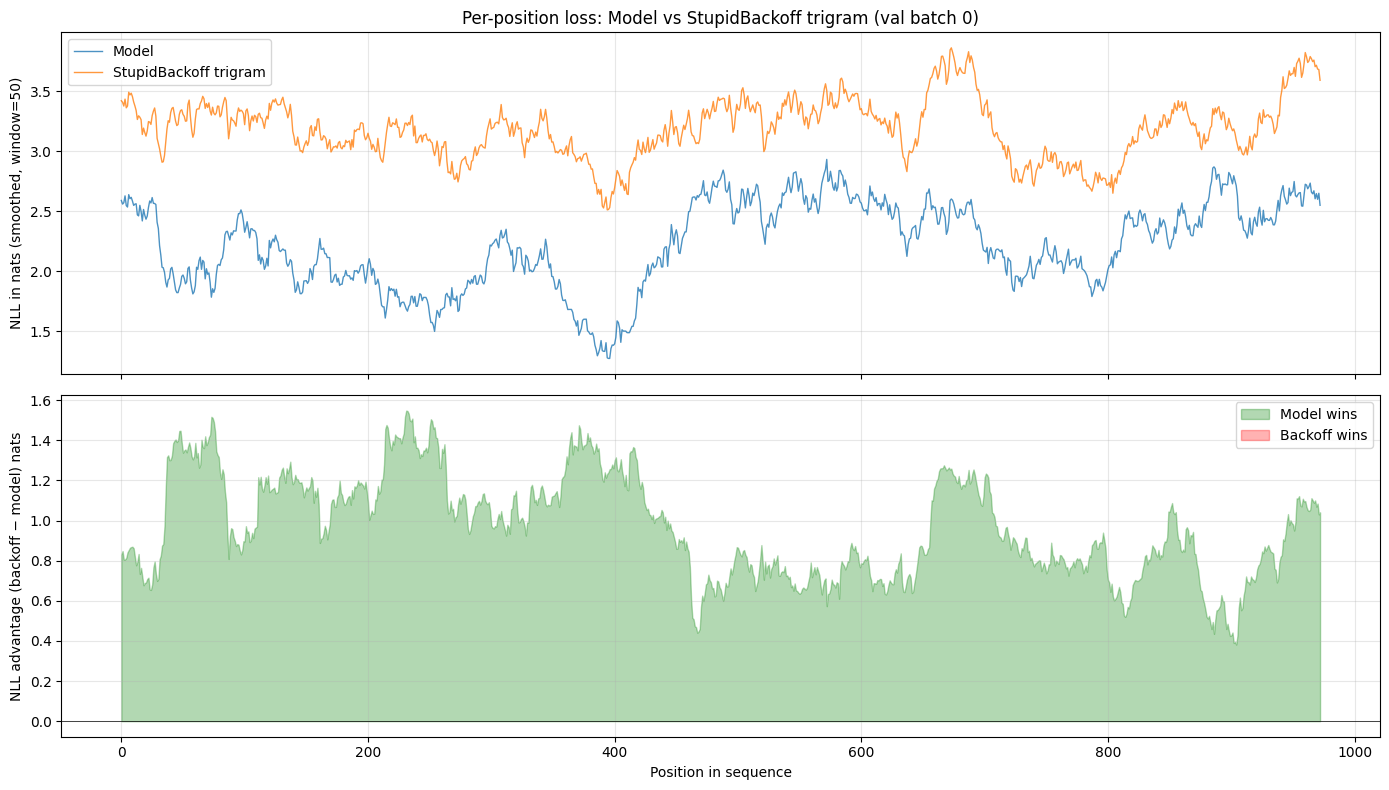


Model wins on 80.7% of positions
Mean advantage: 0.969 nats
Positions where backoff wins most (model struggles):
  pos 851: ctx='about it (' → '3'  adv=-4.20
  pos 908: ctx='blear' → 'ily'  adv=-3.74
  pos 208: ctx='inform the' → '▁'  adv=-3.57
  pos 172: ctx='a fat' → '▁che'  adv=-3.42
  pos 67: ctx='letter' → '▁add'  adv=-3.34


In [24]:
# === Per-position loss comparison: where does the model beat n-grams most? ===
x, y = get_val_batch(0)
tokens = torch.cat([x[0, :1], y[0]], dim=0).tolist()
pieces = [id_to_piece[t] for t in tokens]

# N-gram per-position NLL using StupidBackoff
# Model logit[i] predicts y[0,i] = tokens[i+1], for i in 0..SEQ_LEN-1.
# We skip the first ORDER-1 model positions (not enough context for trigram).
# So n-gram predicts tokens[ORDER]..tokens[SEQ_LEN], same as model positions ORDER-1..SEQ_LEN-1.
ngram_nll_per_pos = []
for i in range(ORDER, SEQ_LEN + 1):  # i indexes into tokens/pieces
    context = tuple(pieces[i - ORDER + 1 : i])
    word = pieces[i]
    ls = lm_backoff.logscore(word, context)  # log2(P)
    ngram_nll_per_pos.append(-ls * ln2)  # → nats
ngram_nll_per_pos = np.array(ngram_nll_per_pos)

# Model per-position NLL (trim first ORDER-1 positions to align)
logits = get_logits(x)
log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
model_nll_full = -log_probs[range(SEQ_LEN), y[0].tolist()].numpy()
model_nll_per_pos = model_nll_full[ORDER - 1 :]

assert len(model_nll_per_pos) == len(ngram_nll_per_pos), (
    f"Length mismatch: model={len(model_nll_per_pos)}, ngram={len(ngram_nll_per_pos)}"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

window = 50
ax = axes[0]
ax.plot(
    np.convolve(model_nll_per_pos, np.ones(window) / window, mode="valid"),
    label="Model",
    alpha=0.8,
    linewidth=1,
)
ax.plot(
    np.convolve(ngram_nll_per_pos, np.ones(window) / window, mode="valid"),
    label="StupidBackoff trigram",
    alpha=0.8,
    linewidth=1,
)
ax.set_ylabel(f"NLL in nats (smoothed, window={window})")
ax.set_title("Per-position loss: Model vs StupidBackoff trigram (val batch 0)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
advantage = ngram_nll_per_pos - model_nll_per_pos
smoothed_adv = np.convolve(advantage, np.ones(window) / window, mode="valid")
ax.fill_between(
    range(len(smoothed_adv)),
    smoothed_adv,
    where=smoothed_adv > 0,
    color="green",
    alpha=0.3,
    label="Model wins",
)
ax.fill_between(
    range(len(smoothed_adv)),
    smoothed_adv,
    where=smoothed_adv < 0,
    color="red",
    alpha=0.3,
    label="Backoff wins",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("NLL advantage (backoff − model) nats")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel wins on {(advantage > 0).mean():.1%} of positions")
print(f"Mean advantage: {advantage.mean():.3f} nats")
print(f"Positions where backoff wins most (model struggles):")
worst = np.argsort(advantage)[:5]
for idx in worst:
    pos = idx + ORDER
    ctx_text = sp.decode(tokens[max(0, pos - 3) : pos])
    next_text = id_to_piece[tokens[pos]]
    print(f"  pos {pos}: ctx='{ctx_text}' → '{next_text}'  adv={advantage[idx]:.2f}")

### Collocation analysis (PMI)

Find token pairs that co-occur much more often than chance — these are patterns the model needs to learn. High-PMI collocations that the model assigns low probability to indicate learning gaps.

In [25]:
# === Pointwise Mutual Information (PMI) for bigrams ===
# PMI(a, b) = log2(P(a,b) / (P(a) * P(b)))

total_unigrams = ngram_counts[1].N()
total_bigram_count = sum(
    c for ctx in ngram_counts[2] for c in ngram_counts[2][ctx].values()
)
min_count = 50

pmi_scores = {}
for ctx in ngram_counts[2]:
    a = ctx[0]
    count_a = ngram_counts[1][a]  # FreqDist: key is the word itself
    for b, count_ab in ngram_counts[2][ctx].items():
        if count_ab < min_count:
            continue
        count_b = ngram_counts[1][b]
        p_ab = count_ab / total_bigram_count
        p_a = count_a / total_unigrams
        p_b = count_b / total_unigrams
        pmi = math.log2(p_ab / (p_a * p_b))
        pmi_scores[(a, b)] = pmi

sorted_pmi = sorted(pmi_scores.items(), key=lambda x: x[1], reverse=True)

print(f"Computed PMI for {len(pmi_scores):,} bigrams (min_count={min_count})")
print(f"\nTop 25 collocations (highest PMI):")
for (a, b), pmi in sorted_pmi[:25]:
    print(f"  PMI={pmi:6.2f}  {a!r:>15s} + {b!r:<15s}")

print(f"\nBottom 25 (most anti-collocated):")
for (a, b), pmi in sorted_pmi[-25:]:
    print(f"  PMI={pmi:6.2f}  {a!r:>15s} + {b!r:<15s}")

Computed PMI for 43,113 bigrams (min_count=50)

Top 25 collocations (highest PMI):
  PMI= 15.31         '<0xDB>' + '<0x8C>'       
  PMI= 14.96         '<0xF0>' + '<0x9F>'       
  PMI= 14.95         '<0xEF>' + '<0xB8>'       
  PMI= 14.63         '<0xC9>' + '<0xAC>'       
  PMI= 14.51         '<0xE1>' + '<0xB9>'       
  PMI= 14.32         '<0x9D>' + '<0x8F>'       
  PMI= 14.22         '<0xE7>' + '<0x9A>'       
  PMI= 13.89         '<0xE0>' + '<0xA4>'       
  PMI= 13.76         '<0xE4>' + '<0xBA>'       
  PMI= 13.53         '<0x82>' + '<0xAC>'       
  PMI= 13.52         '<0x86>' + '<0x92>'       
  PMI= 13.46         '<0xE4>' + '<0xB8>'       
  PMI= 13.45         '<0xC4>' + '<0xAB>'       
  PMI= 13.40         '<0x88>' + '<0x92>'       
  PMI= 13.39         '<0x9F>' + '<0x99>'       
  PMI= 13.33         '<0xE0>' + '<0xB8>'       
  PMI= 13.27         '<0xB9>' + '<0x9B>'       
  PMI= 13.22         '<0xD0>' + '<0xBE>'       
  PMI= 13.20         '<0xD0>' + '<0xB5>'       
  PMI

### Perplexity decomposition: what does the model learn beyond n-grams?

Decompose per-token loss into: (1) unigram-predictable, (2) bigram-predictable, (3) trigram-predictable, (4) model-only.
This shows how much of the model's performance comes from local statistics vs long-range context.

Sanity check — get_logits: 2.2316, compute_loss: 2.2316, delta: 0.000000

=== Cross-entropy per token ===
                          nats      bits     improvement
  Uniform           :   6.9315   10.0000
  Unigram           :   5.9572    8.5944  (−1.406 bits)
  Bigram            :   4.1940    6.0507  (−2.544 bits)
  Trigram           :   3.2015    4.6188  (−1.432 bits)
  Neural model      :   2.2815    3.2916  (−1.327 bits)


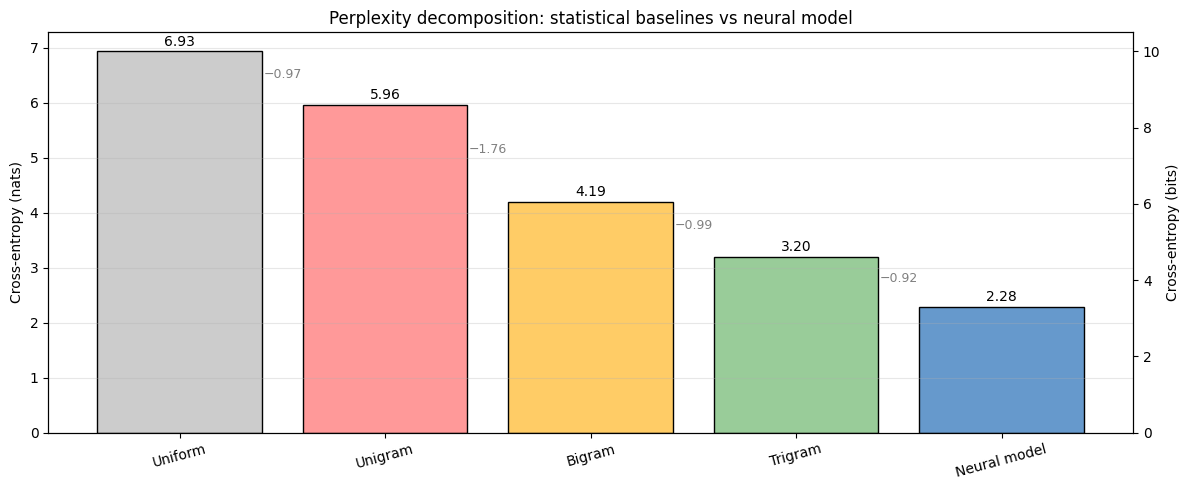

In [ ]:
# === Perplexity decomposition across multiple val batches ===
# Compare: uniform, unigram, bigram, trigram (backoff), neural model.
# Using NLTK's built-in entropy throughout.

N_DECOMPOSE_BATCHES = 5
ln2 = math.log(2)

# Build unigram and bigram StupidBackoff models for the decomposition
lm_uni = StupidBackoff(alpha=0.4, order=1)
lm_uni.fit(
    [list(everygrams(s, max_len=1)) for s in sentences], vocabulary_text=train_flat
)
lm_bi = StupidBackoff(alpha=0.4, order=2)
lm_bi.fit(
    [list(everygrams(s, max_len=2)) for s in sentences], vocabulary_text=train_flat
)

decomp_models = {
    "Unigram": lm_uni,
    "Bigram": lm_bi,
    "Trigram": lm_backoff,
}

# Sanity check: verify get_logits matches compute_loss
x_chk, y_chk = get_val_batch(0)
logits_chk = get_logits(x_chk)
lp_chk = torch.nn.functional.log_softmax(logits_chk, dim=-1)
nll_logits = -lp_chk[range(SEQ_LEN), y_chk[0].tolist()].mean().item()
nll_model = compute_loss(x_chk, y_chk)
print(
    f"Sanity check — get_logits: {nll_logits:.4f}, compute_loss: {nll_model:.4f}, "
    f"delta: {abs(nll_logits - nll_model):.6f}"
)
use_get_logits = abs(nll_logits - nll_model) < 0.05
if not use_get_logits:
    print("⚠ get_logits mismatch — falling back to compute_loss for model NLL")

# Collect per-batch results
results_per_batch = {name: [] for name in decomp_models}
results_per_batch["Uniform"] = []
results_per_batch["Neural model"] = []

for batch_i in range(N_DECOMPOSE_BATCHES):
    x, y = get_val_batch(batch_i)
    tokens = torch.cat([x[0, :1], y[0]], dim=0).tolist()
    pieces = [id_to_piece[t] for t in tokens]

    # Uniform baseline: log(V) nats
    results_per_batch["Uniform"].append(math.log(V))

    # NLTK models: entropy() returns bits → convert to nats
    for name, lm in decomp_models.items():
        test_ngrams = list(nltk_ngrams(pieces, lm.order))
        try:
            h_bits = lm.entropy(test_ngrams)
            results_per_batch[name].append(h_bits * ln2)
        except (ZeroDivisionError, ValueError):
            results_per_batch[name].append(float("nan"))

    # Neural model
    if use_get_logits:
        logits = get_logits(x)
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        m_nll = -log_probs[range(SEQ_LEN), y[0].tolist()].mean().item()
    else:
        m_nll = compute_loss(x, y)
    results_per_batch["Neural model"].append(m_nll)

# Mean across batches
display_order = ["Uniform", "Unigram", "Bigram", "Trigram", "Neural model"]
results_nats = {name: np.nanmean(results_per_batch[name]) for name in display_order}

print(f"\n=== Cross-entropy per token ===")
print(f"  {'':18s}  {'nats':>8s}  {'bits':>8s}  {'improvement':>14s}")
prev = None
for name, nats in results_nats.items():
    bits = nats / ln2
    imp = f"  (−{(prev - nats) / ln2:.3f} bits)" if prev is not None else ""
    print(f"  {name:18s}: {nats:8.4f}  {bits:8.4f}{imp}")
    prev = nats

# Bar chart (nats, with secondary bits axis)
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results_nats.keys())
vals = list(results_nats.values())
colors = ["#cccccc", "#ff9999", "#ffcc66", "#99cc99", "#6699cc"]
bars = ax.bar(names, vals, color=colors, edgecolor="black")
ax.set_ylabel("Cross-entropy (nats)")
ax.set_title("Perplexity decomposition: statistical baselines vs neural model")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.tick_params(axis="x", rotation=15)

ax2 = ax.twinx()
ax2.set_ylabel("Cross-entropy (bits)")
lo, hi = ax.get_ylim()
ax2.set_ylim(lo / ln2, hi / ln2)

for i in range(1, len(vals)):
    gap = vals[i - 1] - vals[i]
    if gap > 0:
        mid_y = (vals[i - 1] + vals[i]) / 2
        ax.annotate(
            f"−{gap:.2f}", xy=(i - 0.5, mid_y), fontsize=9, ha="center", color="gray"
        )
plt.tight_layout()
# plt.savefig("perplexity_decomposition.png")
plt.show()

### Entropy and predictability analysis

Token-level entropy from the n-gram model vs the neural model — where is the model most/least confident?

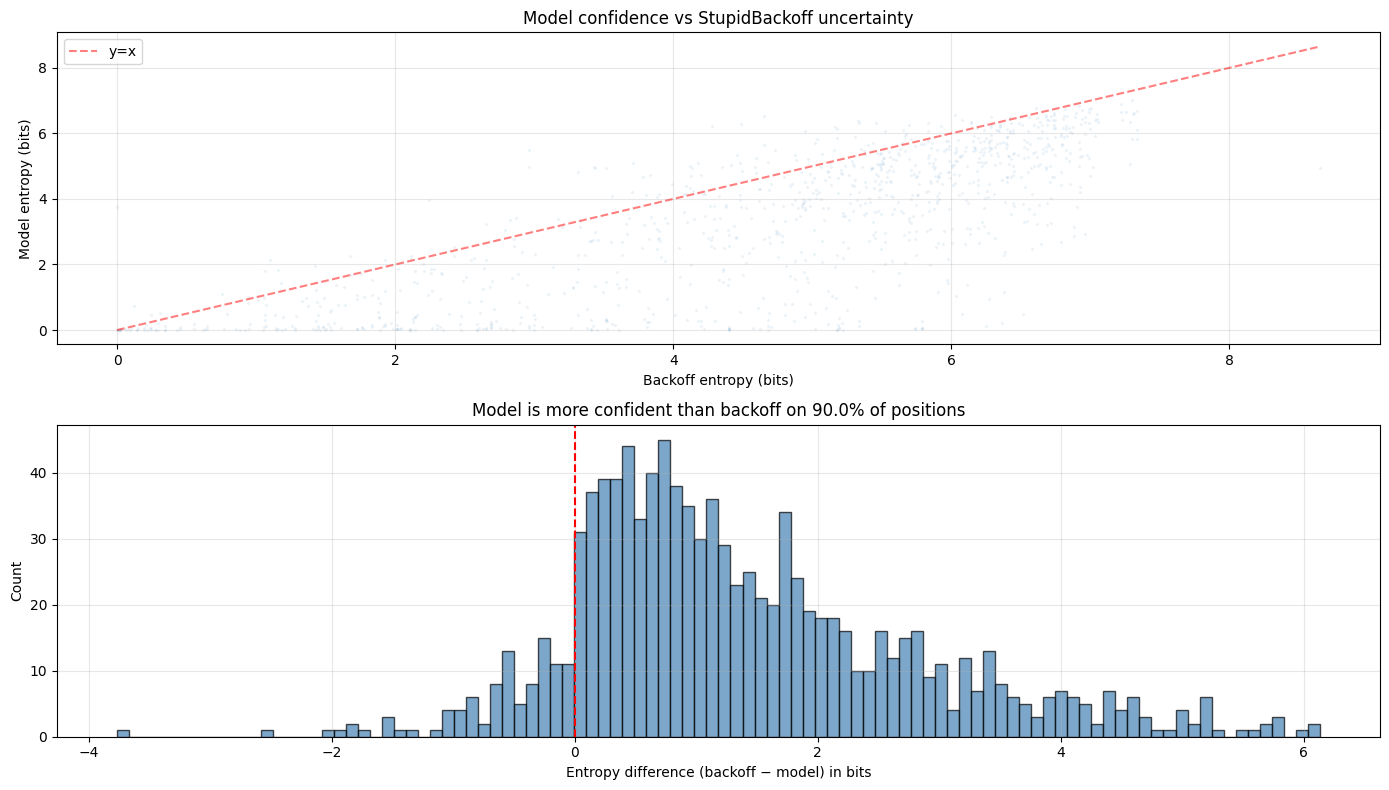

Mean model entropy:   3.246 bits
Mean backoff entropy: 4.624 bits
Model reduces uncertainty by 1.378 bits on average


In [35]:
# === Entropy analysis: model confidence vs n-gram entropy ===
# For each position, compute:
#   - Model entropy: H = -sum(p * log p) from softmax output
#   - Backoff entropy: H of conditional distribution P(· | context)

x, y = get_val_batch(0)
tokens = torch.cat([x[0, :1], y[0]], dim=0).tolist()
pieces = [id_to_piece[t] for t in tokens]
ln2 = math.log(2)

# Model entropy per position (in bits)
logits = get_logits(x)
probs = torch.nn.functional.softmax(logits, dim=-1)
log_p = torch.nn.functional.log_softmax(logits, dim=-1)
model_entropy = -(probs * log_p).sum(dim=-1).numpy() / ln2  # bits

# Backoff conditional entropy per position (in bits)
# Align to model positions ORDER-1..SEQ_LEN-1 (same as per-position loss cell)
backoff_entropy = []
for i in range(ORDER, SEQ_LEN + 1):  # i indexes into pieces
    context = tuple(pieces[i - ORDER + 1 : i])
    cond_fd = lm_backoff.counts[context]
    if cond_fd:
        h = 0.0
        for w in cond_fd:
            ls = lm_backoff.logscore(w, context)  # log2(P)
            p = 2**ls
            if p > 0:
                h -= p * ls
        backoff_entropy.append(h)
    else:
        # Unseen context — fall back to unigram entropy
        h = 0.0
        for w in lm_backoff.counts.unigrams:
            ls = lm_backoff.logscore(w)
            p = 2**ls
            if p > 0:
                h -= p * ls
        backoff_entropy.append(h)
backoff_entropy = np.array(backoff_entropy)

# Align model entropy to same positions
model_entropy_aligned = model_entropy[ORDER - 1 :]

assert len(backoff_entropy) == len(model_entropy_aligned), (
    f"Length mismatch: backoff={len(backoff_entropy)}, model={len(model_entropy_aligned)}"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.scatter(backoff_entropy, model_entropy_aligned, alpha=0.05, s=2, rasterized=True)
max_val = max(backoff_entropy.max(), model_entropy_aligned.max())
ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="y=x")
ax.set_xlabel("Backoff entropy (bits)")
ax.set_ylabel("Model entropy (bits)")
ax.set_title("Model confidence vs StupidBackoff uncertainty")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
entropy_diff = backoff_entropy - model_entropy_aligned
ax.hist(entropy_diff, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Entropy difference (backoff − model) in bits")
ax.set_ylabel("Count")
ax.set_title(
    f"Model is more confident than backoff on {(entropy_diff > 0).mean():.1%} of positions"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean model entropy:   {model_entropy_aligned.mean():.3f} bits")
print(f"Mean backoff entropy: {backoff_entropy.mean():.3f} bits")
print(
    f"Model reduces uncertainty by {backoff_entropy.mean() - model_entropy_aligned.mean():.3f} bits on average"
)

### Further investigation ideas

**Already implemented above:**
- N-gram counts (uni/bi/trigram) with coverage statistics
- Sparse storage analysis (dense vs sparse vs CSR)
- N-gram predictor with stupid backoff vs neural model
- Per-position loss comparison (where does the model beat n-grams?)
- PMI / collocation analysis
- Perplexity decomposition (uniform → unigram → bigram → trigram → model)
- Entropy analysis (model confidence vs bigram uncertainty)

**Worth exploring next:**
1. **Kneser-Ney smoothing** — Replace stupid backoff with KN smoothing for a stronger n-gram baseline. NLTK has `KneserNeyProbDist`. This would give a fairer comparison since backoff underestimates n-gram capability.
2. **Token-type stratified analysis** — Break down model vs n-gram performance by token type (punctuation, common words, rare words, numbers, BOS tokens). Where does long-range context help most?
3. **Zipf's law analysis** — Plot token frequency rank vs frequency on log-log axes. How well does the data follow Zipf? Does the model's probability mass allocation match the empirical Zipf distribution?
4. **Repetition / burstiness** — Measure how "bursty" tokens are (appearing in clusters vs uniformly). Bursty tokens benefit more from context. Compare burstiness score vs model advantage over unigram.
5. **KL divergence: model vs n-gram** — For each context, compute KL(model || ngram) to find where the model's distribution diverges most from n-gram predictions. These are positions where the model has learned something the n-gram can't capture.
6. **Interpolated model** — Build a model that interpolates between n-gram predictions and the neural model (e.g., λ·P_ngram + (1-λ)·P_model). If this improves over the model alone, the model hasn't fully captured local statistics.
7. **Context length ablation** — Mask increasing amounts of context in the neural model and measure loss degradation. At what context length does the model match the trigram? This reveals the model's effective context usage.
8. **Mutual information between positions** — MI(position i, position j) to understand the range of dependencies the model captures beyond what n-grams can.

## Parse training logs and plot training curves

Parse `step:` lines from `models/*/log.txt` into pandas DataFrames and plot loss curves.

In [40]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def parse_log(path: str | Path) -> pd.DataFrame:
    """Parse a training log file into a DataFrame.

    Extracts all `step:` lines and parses key:value pairs into columns.
    Handles both train lines (step, train_loss, train_time, step_avg, tok_s)
    and val lines (step, val_loss, val_bpb, train_time, step_avg).

    Multiple runs appended to the same file are detected by step resets
    (current step <= previous step) and tagged with a `run` column (0-indexed).

    Returns a DataFrame with one row per `step:` line.
    """
    path = Path(path)
    rows = []
    pattern = re.compile(r"(\w+):([\w./+-]+)")
    unit_suffixes = ("ms", "s", "x")
    run_idx = 0
    prev_step = -1

    for line in path.read_text().splitlines():
        stripped = line.strip()
        if not stripped.startswith("step:"):
            continue
        fields = dict(pattern.findall(stripped))
        if not fields:
            continue

        row = {}
        for k, v in fields.items():
            if k == "step" and "/" in v:
                parts = v.split("/")
                row["step"] = int(parts[0])
                row["total_steps"] = int(parts[1])
            else:
                v_clean = v
                for suffix in unit_suffixes:
                    if v_clean.endswith(suffix) and len(v_clean) > len(suffix):
                        v_clean = v_clean[: -len(suffix)]
                        break
                try:
                    row[k] = int(v_clean)
                except ValueError:
                    try:
                        row[k] = float(v_clean)
                    except ValueError:
                        row[k] = v

        # Detect run boundary: step resets to a value <= previous step
        cur_step = row.get("step", prev_step + 1)
        if cur_step <= prev_step and prev_step > 0:
            run_idx += 1
        prev_step = cur_step
        row["run"] = run_idx
        rows.append(row)

    df = pd.DataFrame(rows)
    if "train_time" in df.columns:
        df["train_time_min"] = df["train_time"] / 60_000.0
    return df


def split_train_val(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split a parsed log DataFrame into train and val DataFrames."""
    is_val = (
        df["val_loss"].notna()
        if "val_loss" in df.columns
        else pd.Series(False, index=df.index)
    )
    return df[~is_val].copy(), df[is_val].copy()


def get_runs(df: pd.DataFrame) -> dict[int, pd.DataFrame]:
    """Split a parsed log DataFrame by run index."""
    return {run: group for run, group in df.groupby("run")}


# Parse all log files
log_dir = Path("models")
logs = {}
for f in sorted(log_dir.glob("*/log.txt")):
    name = f.parent.name
    df = parse_log(f)
    if len(df) > 0:
        logs[name] = df
        n_runs = df["run"].nunique()
        train, val = split_train_val(df)
        print(
            f"{name}: {len(df)} step lines, {n_runs} run(s) ({len(train)} train, {len(val)} val)"
        )

print(f"\nParsed {len(logs)} log files. Access via logs['name'].")
print("Use get_runs(df) to split into per-run DataFrames.")

baseline_20k_iters_seq128_20260325_001904: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq16384_20260325_041510: 16 step lines, 1 run(s) (15 train, 1 val)
baseline_20k_iters_seq16_20260324_222834: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq2048_20260325_022843: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq256_20260325_010148: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq2_20260324_205335: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq32_20260324_225950: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq4096_20260325_030146: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq4_20260324_213532: 106 step lines, 1 run(s) (105 train, 1 val)
baseline_20k_iters_seq512_20260325_013110: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq64_20260324_233555: 212 step lines, 2 run(s) (210 train, 2 val)
baseline_20k_iters_seq8192_20260325_033624: 212 

In [41]:
# Quick look at one DataFrame
sample_name = list(logs.keys())[0]
print(f"Sample: logs['{sample_name}']")
logs[sample_name].head(10)

Sample: logs['baseline_20k_iters_seq128_20260325_001904']


,step,total_steps,val_loss,val_bpb,train_time,step_avg,run,train_loss,train_time_min
0,0,20000,6.9353,4.1569,0,0.02,0,NaN,0.000000
1,1,20000,NaN,NaN,61,61.15,0,6.9370,0.001017
2,2,20000,NaN,NaN,137,68.42,0,17.2577,0.002283
3,3,20000,NaN,NaN,240,80.12,0,9.6280,0.004000
4,4,20000,NaN,NaN,297,74.28,0,6.6717,0.004950
5,5,20000,NaN,NaN,355,70.93,0,6.6084,0.005917
6,6,20000,NaN,NaN,418,69.62,0,6.6153,0.006967
7,7,20000,NaN,NaN,483,68.93,0,6.3716,0.008050
8,8,20000,NaN,NaN,562,70.30,0,6.2271,0.009367
9,9,20000,NaN,NaN,645,71.64,0,6.0987,0.010750


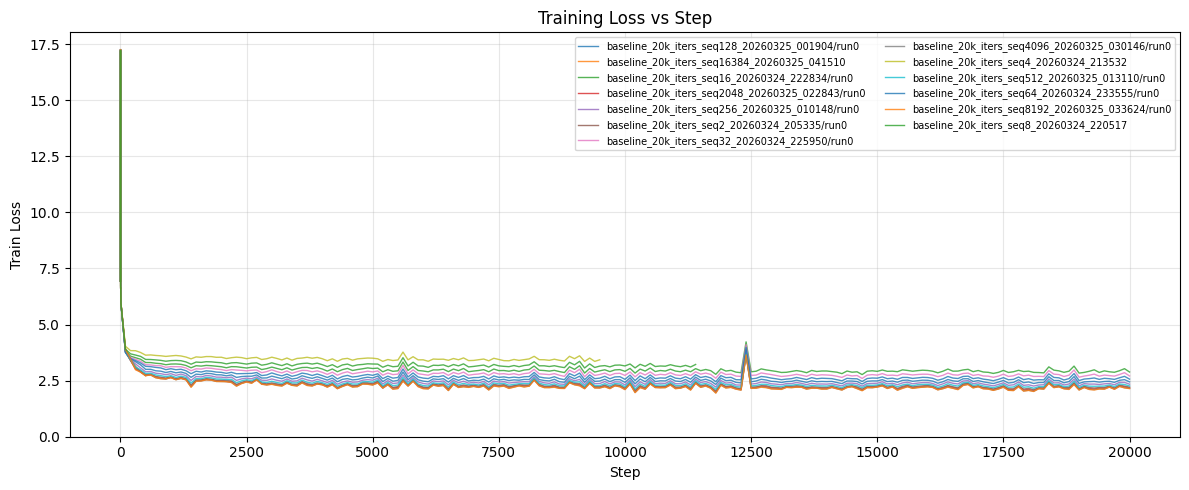

In [42]:
# --- Training loss vs step (each run as a separate line) ---
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in logs.items():
    for run_idx, run_df in get_runs(df).items():
        train, _ = split_train_val(run_df)
        if len(train) == 0 or "train_loss" not in train.columns:
            continue
        t = train.dropna(subset=["train_loss"])
        n_runs = df["run"].nunique()
        label = f"{name}" if n_runs == 1 else f"{name}/run{run_idx}"
        ax.plot(t["step"], t["train_loss"], label=label, alpha=0.8, linewidth=1)

ax.set_xlabel("Step")
ax.set_ylabel("Train Loss")
ax.set_title("Training Loss vs Step")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

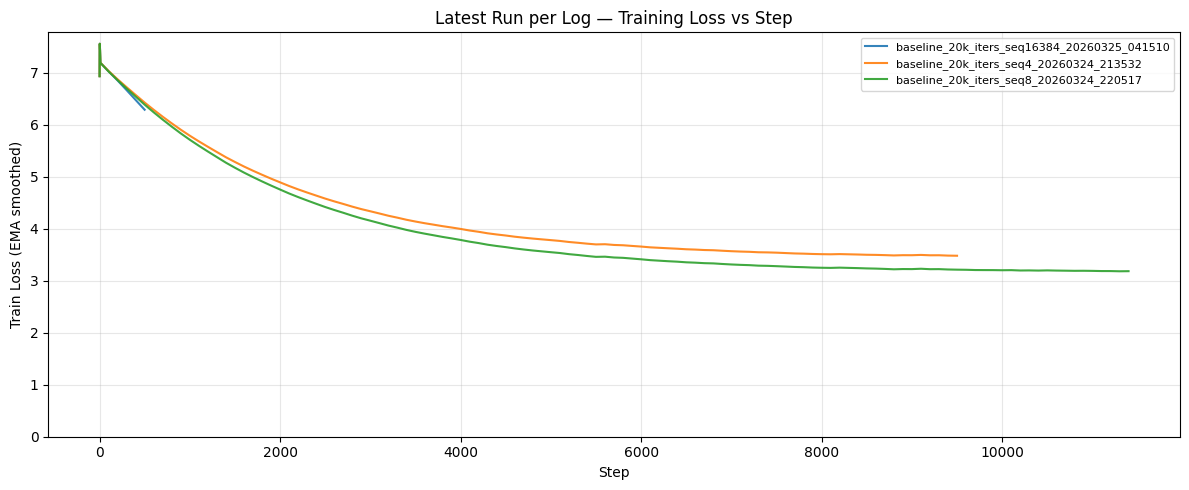

In [43]:
# --- Latest run per file: smoothed training loss vs step ---
EMA_ALPHA = 0.05  # smaller = smoother (0.05 ≈ ~20-step window)

fig, ax = plt.subplots(figsize=(12, 5))
for name, df in logs.items():
    last_run = df["run"].max()
    run_df = df[df["run"] == last_run]
    train, _ = split_train_val(run_df)
    if len(train) == 0 or "train_loss" not in train.columns:
        continue
    t = train.dropna(subset=["train_loss"])
    if len(t) < 2:
        continue
    smoothed = t["train_loss"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
    ax.plot(t["step"].values, smoothed.values, label=name, alpha=0.9, linewidth=1.5)

ax.set_xlabel("Step")
ax.set_ylabel("Train Loss (EMA smoothed)")
ax.set_title("Latest Run per Log — Training Loss vs Step")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
from itertools import cycle

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(colors)


/var/folders/7p/jwbp433d7zd84389fs3c3bk80000gn/T/ipykernel_36016/3740400046.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=7, ncol=2)


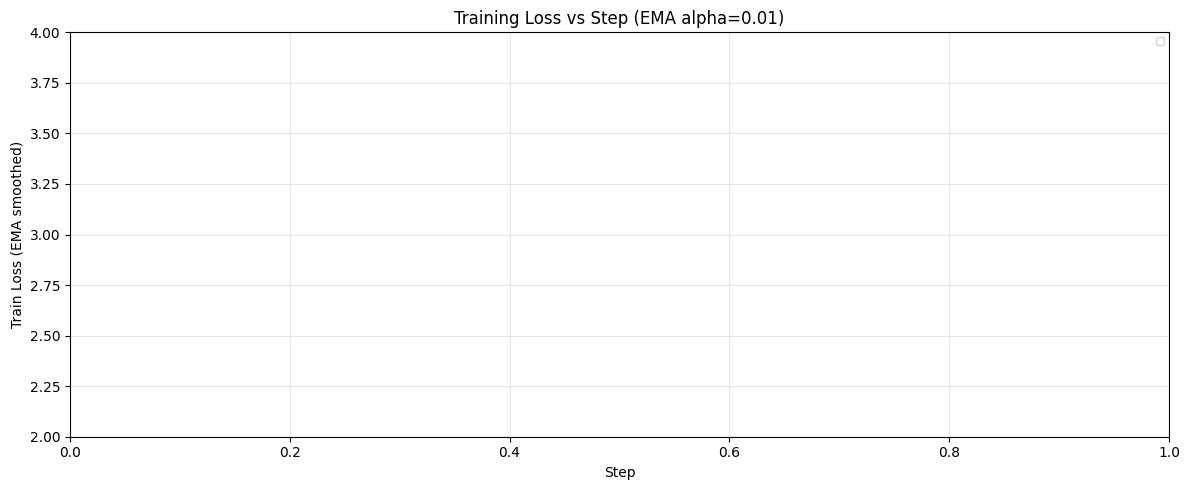

In [45]:
# --- Training loss vs step (smoothed with EMA) ---
EMA_ALPHA = 0.01  # smaller = smoother (0.05 ≈ ~20-step window)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, df) in enumerate(logs.items()):
    color = next(color_cycle)
    for run_idx, run_df in get_runs(df).items():
        train, _ = split_train_val(run_df)
        if len(train) == 0 or "train_loss" not in train.columns:
            continue
        t = train.dropna(subset=["train_loss"])
        if len(t) < 1000:
            continue
        smoothed = t["train_loss"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
        n_runs = df["run"].nunique()
        label = f"{name}" if n_runs == 1 else f"{name}/run{run_idx}"
        ax.plot(
            t["step"].values,
            smoothed.values,
            label=label,
            alpha=0.9,
            linewidth=1.5,
            color=color,
        )

ax.set_xlabel("Step")
ax.set_ylabel("Train Loss (EMA smoothed)")
ax.set_title(f"Training Loss vs Step (EMA alpha={EMA_ALPHA})")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.set_ylim(2, 4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

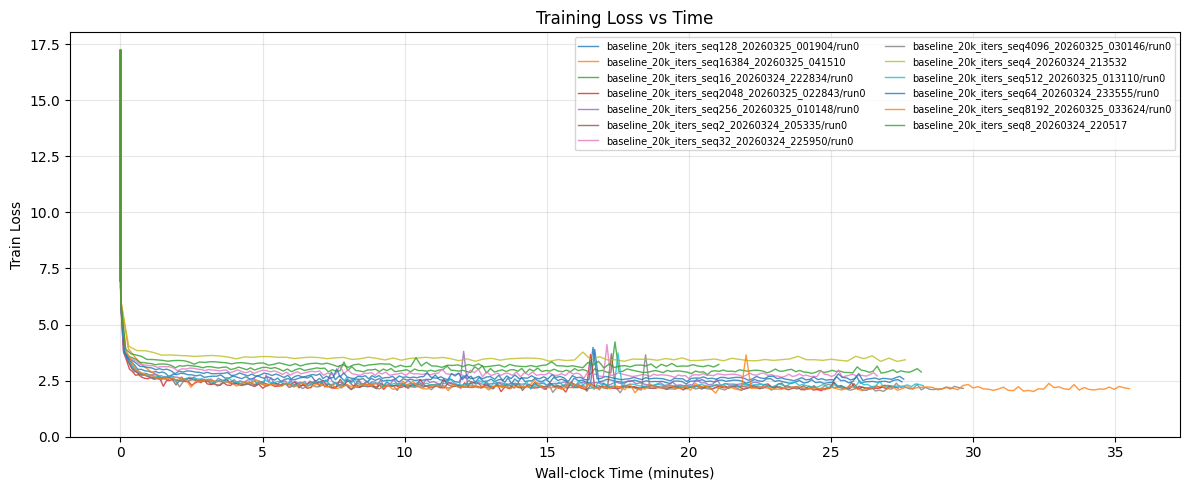

In [46]:
# --- Training loss vs wall-clock time (minutes), per run ---
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in logs.items():
    for run_idx, run_df in get_runs(df).items():
        train, _ = split_train_val(run_df)
        if (
            len(train) == 0
            or "train_loss" not in train.columns
            or "train_time_min" not in train.columns
        ):
            continue
        t = train.dropna(subset=["train_loss"])
        n_runs = df["run"].nunique()
        label = f"{name}" if n_runs == 1 else f"{name}/run{run_idx}"
        ax.plot(
            t["train_time_min"], t["train_loss"], label=label, alpha=0.8, linewidth=1
        )

ax.set_xlabel("Wall-clock Time (minutes)")
ax.set_ylabel("Train Loss")
ax.set_title("Training Loss vs Time")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IndexError: list index out of range

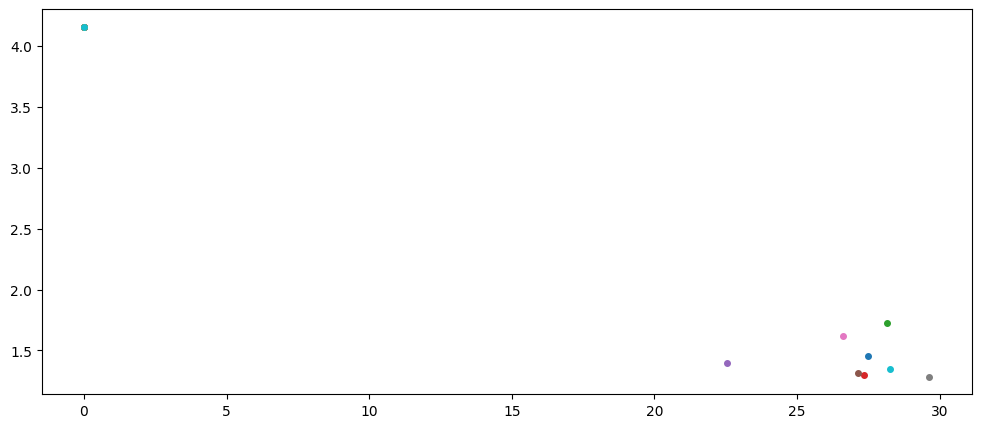

In [47]:
# --- Validation BPB vs time (if available), per run ---
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
has_val = False
fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, df) in enumerate(logs.items()):
    color = color_cycle[i]
    for run_idx, run_df in get_runs(df).items():
        _, val = split_train_val(run_df)
        if len(val) == 0 or "val_bpb" not in val.columns:
            continue
        v = val.dropna(subset=["val_bpb"])
        if len(v) == 0:
            continue
        has_val = True
        n_runs = df["run"].nunique()
        label = f"{name}" if n_runs == 1 else f"{name}/run{run_idx}"
        ax.plot(
            v["train_time_min"],
            v["val_bpb"],
            "o-",
            label=label,
            markersize=4,
            color=color,
        )

if has_val:
    ax.set_xlabel("Wall-clock Time (minutes)")
    ax.set_ylabel("Validation BPB")
    ax.set_title("Validation BPB vs Time")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("No validation BPB data found in any log.")

/var/folders/7p/jwbp433d7zd84389fs3c3bk80000gn/T/ipykernel_36016/3793051398.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", fontsize=7, ncol=2)


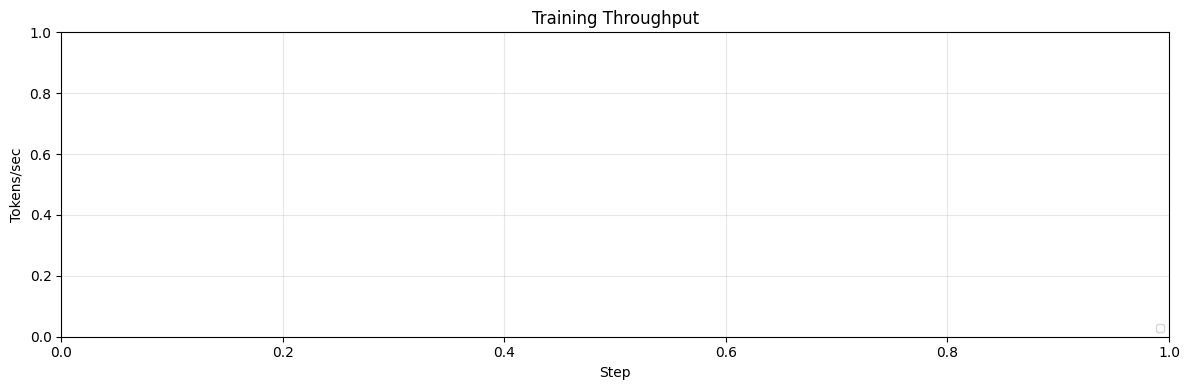

In [48]:
# --- Throughput (tok/s) vs step, per run ---
fig, ax = plt.subplots(figsize=(12, 4))
for name, df in logs.items():
    for run_idx, run_df in get_runs(df).items():
        train, _ = split_train_val(run_df)
        if len(train) == 0 or "tok_s" not in train.columns:
            continue
        t = train.dropna(subset=["tok_s"])
        n_runs = df["run"].nunique()
        label = f"{name}" if n_runs == 1 else f"{name}/run{run_idx}"
        ax.plot(t["step"], t["tok_s"], label=label, alpha=0.7, linewidth=1)

ax.set_xlabel("Step")
ax.set_ylabel("Tokens/sec")
ax.set_title("Training Throughput")
ax.legend(loc="lower right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()